# Day 06 — Prompt Workbench (hands-on)

**Pick one real task. Write 10 prompts across zero-shot / few-shot / chain-of-thought / system
framing. Run them all through the same harness and compare accuracy, token cost, and latency.**

This is the day the Week 2 concepts become a habit: never ship a prompt you didn't measure
against at least one alternative.

The task today: **triage a support ticket** → output strict JSON
`{"category": <one of 5>, "priority": "low|medium|high", "needs_human": true|false}`.

## Agenda (60 min)

| # | Segment | Time |
| - | ------- | ---- |
| 0 | The task, the gold set, the rules of the bake-off | 5 min |
| 1 | The model backend: a local mock now, real API later | 8 min |
| 2 | The scoring function: partial credit + format validity | 8 min |
| 3 | Write the 10 prompts | 15 min |
| 4 | Run the bake-off | 10 min |
| 5 | Read the results: accuracy vs cost frontier | 9 min |
| 6 | Exercises + quiz | 5 min |

Kernel: **Python (ai-upskill)**.

In [1]:
import json, time, re, textwrap
import numpy as np
import matplotlib.pyplot as plt
import tiktoken

rng = np.random.default_rng(7)
enc = tiktoken.get_encoding("cl100k_base")
ntok = lambda s: len(enc.encode(s if isinstance(s, str) else json.dumps(s)))
print("ready")

ready


## 0 — The task and the gold set (5 min)

`CATEGORIES = billing, bug, feature_request, account, other`. A ticket is `high` priority if
it mentions money lost, outage, or data loss; `needs_human` if it's angry, legal, or a refund
over $100. These rules are our **ground truth** — in real life you'd label ~50–200 examples by
hand. We use 12 so the notebook runs fast; the method is identical at 200.

In [2]:
GOLD = [
    ("I was charged twice for my subscription this month, please refund $240.",
     {"category": "billing", "priority": "high", "needs_human": True}),
    ("The export button does nothing when I click it on Firefox.",
     {"category": "bug", "priority": "medium", "needs_human": False}),
    ("It would be great if you could add dark mode to the dashboard.",
     {"category": "feature_request", "priority": "low", "needs_human": False}),
    ("I can't log in, it says my account is locked and I have a demo in 10 minutes!!!",
     {"category": "account", "priority": "high", "needs_human": True}),
    ("How do I change the email address on my account?",
     {"category": "account", "priority": "low", "needs_human": False}),
    ("Your last update deleted all my saved reports. This is unacceptable.",
     {"category": "bug", "priority": "high", "needs_human": True}),
    ("Small typo on the pricing page: 'montly' should be 'monthly'.",
     {"category": "other", "priority": "low", "needs_human": False}),
    ("The API has been returning 503 for the past hour, our production is down.",
     {"category": "bug", "priority": "high", "needs_human": True}),
    ("Can I get an invoice with my company VAT number on it?",
     {"category": "billing", "priority": "medium", "needs_human": False}),
    ("Please cancel my account, I no longer need the service. No hard feelings.",
     {"category": "account", "priority": "medium", "needs_human": False}),
    ("Would love a Slack integration for notifications.",
     {"category": "feature_request", "priority": "low", "needs_human": False}),
    ("I think your terms of service violate GDPR and my lawyer agrees.",
     {"category": "other", "priority": "high", "needs_human": True}),
]
CATEGORIES = ["billing", "bug", "feature_request", "account", "other"]
print(len(GOLD), "labeled tickets")

12 labeled tickets


## 1 — The model backend (8 min)

We need a callable `call_model(system, user) -> (text, latency_s)`. Today it's a **local mock**
that is deliberately imperfect: it has decent category instincts but is sloppy about priority
and JSON formatting *unless the prompt helps it*. That's what lets different prompts score
differently. Swap in the real Anthropic client (bottom of this cell) when you have a key —
every downstream cell is unchanged.

In [3]:
# ---------- LOCAL MOCK MODEL ----------
_CAT_HINTS = {
    "billing": ["charged", "refund", "invoice", "payment", "vat", "subscription", "$"],
    "bug": ["error", "503", "does nothing", "deleted", "broken", "crash", "doesn't work", "down"],
    "feature_request": ["would be great", "would love", "add ", "integration", "feature", "wish"],
    "account": ["log in", "login", "locked", "cancel my account", "email address", "password"],
}
_HIGH = ["refund $2", "$240", "production is down", "outage", "deleted all", "503 for the past hour",
         "locked", "gdpr", "lawyer", "unacceptable", "!!!"]
_HUMAN = ["lawyer", "gdpr", "unacceptable", "!!!", "refund $2", "$240", "production is down", "locked"]

def _mock_reason(user):
    u = user.lower()
    cat = "other"
    best = 0
    for c, hints in _CAT_HINTS.items():
        s = sum(h in u for h in hints)
        if s > best: best, cat = s, c
    prio = "high" if any(h.lower() in u for h in _HIGH) else ("medium" if any(
        k in u for k in ["invoice", "cancel", "firefox", "503"]) else "low")
    human = any(h.lower() in u for h in _HUMAN)
    return {"category": cat, "priority": prio, "needs_human": human}

def call_model(system, user, _mode="mock", temperature=0.0):
    t0 = time.perf_counter()
    ans = _mock_reason(user)

    sys_l = (system or "").lower()
    # The mock "respects" the prompt in measurable ways:
    wants_cot = "step by step" in sys_l or "reason" in sys_l or "think" in sys_l
    wants_json = "json" in sys_l or "{" in (system or "")
    has_examples = "example" in sys_l or "ticket:" in sys_l

    # Without JSON instruction, it sometimes wraps output in prose -> format failures.
    if not wants_json and rng.random() < 0.5:
        body = f"This looks like a {ans['category']} issue, priority {ans['priority']}."
        time.sleep(0.001)
        return body, time.perf_counter() - t0

    # Few-shot sharpens priority calls; CoT sharpens needs_human; both help a bit.
    if not has_examples and rng.random() < 0.35:
        ans["priority"] = rng.choice(["low", "medium", "high"])
    if not wants_cot and rng.random() < 0.30:
        ans["needs_human"] = bool(rng.random() < 0.5)

    prefix = ""
    if wants_cot:
        prefix = (f"Reasoning: mentions {'money' if '$' in user else 'a workflow issue'}; "
                  f"tone is {'urgent' if '!' in user else 'calm'}.\n")
    time.sleep(0.001 + 0.001 * wants_cot + 0.0005 * has_examples)
    return prefix + json.dumps(ans), time.perf_counter() - t0

# ---------- REAL BACKEND (uncomment when you have a key) ----------
# import os, anthropic          # pip: add 'anthropic' to root requirements.txt
# _client = anthropic.Anthropic(api_key=os.environ["ANTHROPIC_API_KEY"])
# def call_model(system, user, _mode="api", temperature=0.0):
#     t0 = time.perf_counter()
#     r = _client.messages.create(
#         model="claude-sonnet-5", max_tokens=300, temperature=temperature,
#         system=system, messages=[{"role": "user", "content": user}])
#     return r.content[0].text, time.perf_counter() - t0

print(call_model("Return JSON only.", GOLD[0][0]))

('{"category": "billing", "priority": "high", "needs_human": true}', 0.001511540962383151)


## 2 — The scoring function (8 min)

Score each response on:
- **format_ok** (1/0): did it parse as JSON with the 3 required keys and valid values?
- **field accuracy**: fraction of `category`, `priority`, `needs_human` that match gold.
- combined **score** = `0` if not parseable, else field accuracy.

This partial-credit design matters: a prompt that's format-fragile but semantically smart, and
one that's always valid JSON but wrong, are different problems needing different fixes.

In [4]:
def extract_json(text):
    m = re.search(r"\{.*\}", text, re.DOTALL)
    if not m: return None
    try:
        obj = json.loads(m.group(0))
    except json.JSONDecodeError:
        return None
    return obj

def score_response(text, gold):
    obj = extract_json(text)
    keys = {"category", "priority", "needs_human"}
    format_ok = bool(obj) and keys <= set(obj) and \
        obj.get("category") in CATEGORIES and obj.get("priority") in {"low","medium","high"} and \
        isinstance(obj.get("needs_human"), bool)
    if not format_ok:
        return {"format_ok": 0, "fields": 0.0, "score": 0.0}
    fields = np.mean([obj["category"] == gold["category"],
                      obj["priority"] == gold["priority"],
                      obj["needs_human"] == gold["needs_human"]])
    return {"format_ok": 1, "fields": float(fields), "score": float(fields)}

print(score_response('{"category":"billing","priority":"high","needs_human":true}', GOLD[0][1]))
print(score_response('probably a billing thing', GOLD[0][1]))

{'format_ok': 1, 'fields': 1.0, 'score': 1.0}
{'format_ok': 0, 'fields': 0.0, 'score': 0.0}


## 3 — The 10 prompts (15 min)

Each entry is `(name, technique, system_prompt, user_template)`. `user_template` gets
`.format(ticket=...)`. Read them — they escalate from bare instruction to few-shot CoT with a
rigid schema.

In [5]:
SCHEMA = '{"category": "billing|bug|feature_request|account|other", "priority": "low|medium|high", "needs_human": true|false}'

EXAMPLES = textwrap.dedent('''\
    Ticket: "You billed me for a plan I cancelled, I want my $80 back."
    Output: {"category": "billing", "priority": "high", "needs_human": true}
    Ticket: "The search box is a little slow sometimes."
    Output: {"category": "bug", "priority": "low", "needs_human": false}
    Ticket: "Please add CSV export to reports."
    Output: {"category": "feature_request", "priority": "low", "needs_human": false}
''')

RULES = textwrap.dedent('''\
    Priority is high if the ticket mentions money lost, an outage, or data loss.
    needs_human is true if the ticket is angry, mentions legal/lawyer/GDPR, or a refund over $100.
''')

PROMPTS = [
 ("p01_zero_bare", "zero-shot",
  "You triage support tickets.",
  'Triage this ticket: "{ticket}"'),

 ("p02_zero_json", "zero-shot",
  "You triage support tickets. Respond with JSON only, no prose.",
  'Triage this ticket: "{ticket}"'),

 ("p03_zero_schema", "zero-shot",
  f"You triage support tickets. Output exactly this JSON schema and nothing else:\n{SCHEMA}",
  'Ticket: "{ticket}"'),

 ("p04_zero_schema_rules", "zero-shot",
  f"You triage support tickets. Rules:\n{RULES}\nOutput exactly this JSON and nothing else:\n{SCHEMA}",
  'Ticket: "{ticket}"'),

 ("p05_fewshot", "few-shot",
  f"You triage support tickets. Output JSON matching this schema:\n{SCHEMA}\nExamples:\n{EXAMPLES}",
  'Ticket: "{ticket}"'),

 ("p06_fewshot_rules", "few-shot",
  f"You triage support tickets.\n{RULES}\nSchema:\n{SCHEMA}\nExamples:\n{EXAMPLES}",
  'Ticket: "{ticket}"'),

 ("p07_cot", "chain-of-thought",
  f"You triage support tickets. Think step by step about category, then priority, then whether "
  f"a human is needed. Then output JSON on the last line matching:\n{SCHEMA}",
  'Ticket: "{ticket}"'),

 ("p08_cot_rules", "chain-of-thought",
  f"You triage support tickets.\n{RULES}\nReason step by step, then put the JSON on the final "
  f"line, matching:\n{SCHEMA}",
  'Ticket: "{ticket}"'),

 ("p09_fewshot_cot", "few-shot + CoT",
  f"You triage support tickets.\n{RULES}\nReason step by step, then output JSON on the last line.\n"
  f"Schema:\n{SCHEMA}\nExamples:\n{EXAMPLES}",
  'Ticket: "{ticket}"'),

 ("p10_fewshot_cot_strict", "few-shot + CoT",
  f"You are a support triage system. Follow the rules exactly.\n{RULES}\n"
  f"Process: (1) name the category, (2) check each high-priority trigger, (3) check each "
  f"needs_human trigger, (4) emit JSON on the final line, no trailing text.\n"
  f"Schema:\n{SCHEMA}\nExamples:\n{EXAMPLES}",
  'Ticket: "{ticket}"'),
]
print(len(PROMPTS), "prompts;  system-prompt token costs:")
for name, tech, sysp, _ in PROMPTS:
    print(f"  {name:26s} {tech:16s} {ntok(sysp):4d} tok")

10 prompts;  system-prompt token costs:
  p01_zero_bare              zero-shot           6 tok
  p02_zero_json              zero-shot          14 tok
  p03_zero_schema            zero-shot          48 tok
  p04_zero_schema_rules      zero-shot          92 tok
  p05_fewshot                few-shot          149 tok
  p06_fewshot_rules          few-shot          188 tok
  p07_cot                    chain-of-thought   65 tok
  p08_cot_rules              chain-of-thought   98 tok
  p09_fewshot_cot            few-shot + CoT    201 tok
  p10_fewshot_cot_strict     few-shot + CoT    237 tok


## 4 — Run the bake-off (10 min)

For each prompt × each gold ticket: call the model, score it, record tokens in/out and latency.
Repeat `N_REPEATS` times because the mock (like a real model at temperature > 0) is stochastic.

In [6]:
N_REPEATS = 5

def run_prompt(name, tech, sysp, utmpl):
    rows = []
    for rep in range(N_REPEATS):
        for ticket, gold in GOLD:
            user = utmpl.format(ticket=ticket)
            text, lat = call_model(sysp, user)
            sc = score_response(text, gold)
            rows.append(dict(prompt=name, tech=tech, rep=rep,
                             tok_in=ntok(sysp) + ntok(user), tok_out=ntok(text),
                             latency=lat, **sc))
    return rows

all_rows = []
for p in PROMPTS:
    all_rows += run_prompt(*p)
print("collected", len(all_rows), "runs")

# aggregate
def agg(rows):
    import collections
    by = collections.defaultdict(list)
    for r in rows:
        by[r["prompt"]].append(r)
    out = []
    for name, rs in by.items():
        out.append(dict(
            prompt=name, tech=rs[0]["tech"],
            score=np.mean([r["score"] for r in rs]),
            format_ok=np.mean([r["format_ok"] for r in rs]),
            tok_in=np.mean([r["tok_in"] for r in rs]),
            tok_out=np.mean([r["tok_out"] for r in rs]),
            latency_ms=1e3*np.mean([r["latency"] for r in rs]),
        ))
    return sorted(out, key=lambda d: -d["score"])

summary = agg(all_rows)
print(f"\n{'prompt':26s} {'technique':16s} {'score':>6} {'fmt_ok':>7} {'tok_in':>7} {'tok_out':>8} {'ms':>6}")
for d in summary:
    print(f"{d['prompt']:26s} {d['tech']:16s} {d['score']:6.2f} {d['format_ok']:7.2f} "
          f"{d['tok_in']:7.0f} {d['tok_out']:8.1f} {d['latency_ms']:6.2f}")

collected 600 runs

prompt                     technique         score  fmt_ok  tok_in  tok_out     ms
p09_fewshot_cot            few-shot + CoT     1.00    1.00     218     30.0   3.18
p10_fewshot_cot_strict     few-shot + CoT     0.96    1.00     254     18.2   1.96
p05_fewshot                few-shot           0.95    1.00     166     18.2   1.98
p06_fewshot_rules          few-shot           0.94    1.00     205     18.2   2.02
p07_cot                    chain-of-thought   0.92    1.00      82     30.0   2.61
p08_cot_rules              chain-of-thought   0.92    1.00     115     30.0   2.61
p04_zero_schema_rules      zero-shot          0.89    1.00     109     18.2   1.41
p03_zero_schema            zero-shot          0.87    1.00      65     18.2   1.35
p02_zero_json              zero-shot          0.87    1.00      34     18.2   1.28
p01_zero_bare              zero-shot          0.45    0.52      26     14.3   1.28


## 5 — Read the results: the accuracy/cost frontier (9 min)

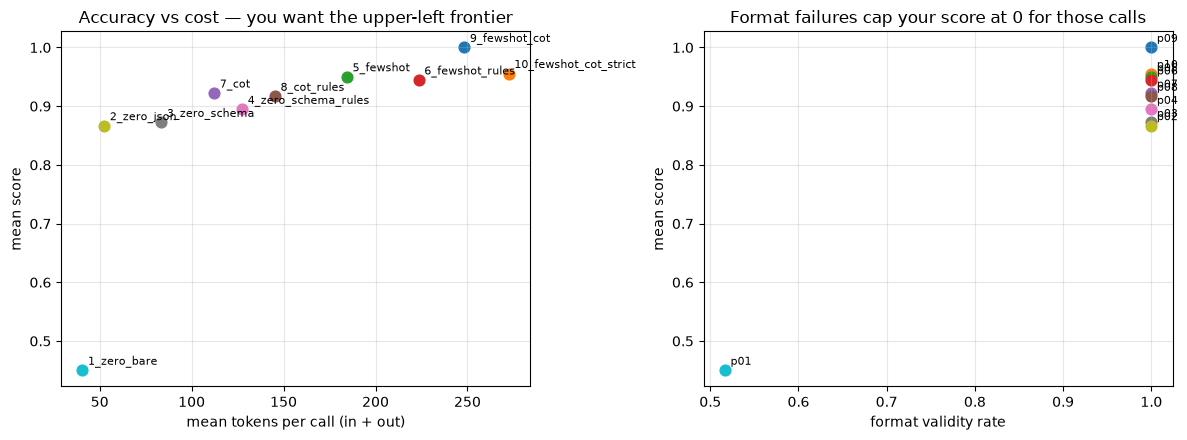

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

# left: score vs total token cost, labelled
for d in summary:
    cost = d["tok_in"] + d["tok_out"]
    ax[0].scatter(cost, d["score"], s=60)
    ax[0].annotate(d["prompt"].replace("p0","").replace("p",""), (cost, d["score"]),
                   fontsize=8, xytext=(4,4), textcoords="offset points")
ax[0].set_xlabel("mean tokens per call (in + out)"); ax[0].set_ylabel("mean score")
ax[0].set_title("Accuracy vs cost — you want the upper-left frontier"); ax[0].grid(alpha=.3)

# right: format validity vs score
for d in summary:
    ax[1].scatter(d["format_ok"], d["score"], s=60)
    ax[1].annotate(d["prompt"].split("_",1)[0], (d["format_ok"], d["score"]),
                   fontsize=8, xytext=(4,4), textcoords="offset points")
ax[1].set_xlabel("format validity rate"); ax[1].set_ylabel("mean score")
ax[1].set_title("Format failures cap your score at 0 for those calls"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

In [8]:
best = summary[0]
cheapest_good = min((d for d in summary if d["score"] >= 0.9*best["score"]),
                    key=lambda d: d["tok_in"] + d["tok_out"])
print(f"Best score          : {best['prompt']} ({best['score']:.2f}) at "
      f"{best['tok_in']+best['tok_out']:.0f} tok/call")
print(f"Cheapest within 10%  : {cheapest_good['prompt']} ({cheapest_good['score']:.2f}) at "
      f"{cheapest_good['tok_in']+cheapest_good['tok_out']:.0f} tok/call")
print()
print("Typical lessons this bake-off surfaces:")
print(" - naming JSON / giving a schema is the single biggest jump in format validity")
print(" - rules text improves priority/needs_human accuracy more than examples alone")
print(" - few-shot + CoT usually wins on score but costs 3-6x the tokens and more latency")
print(" - there's often a mid prompt (schema + rules, no CoT) that gets ~90% at ~30% the cost")

Best score          : p09_fewshot_cot (1.00) at 248 tok/call
Cheapest within 10%  : p07_cot (0.92) at 112 tok/call

Typical lessons this bake-off surfaces:
 - naming JSON / giving a schema is the single biggest jump in format validity
 - rules text improves priority/needs_human accuracy more than examples alone
 - few-shot + CoT usually wins on score but costs 3-6x the tokens and more latency
 - there's often a mid prompt (schema + rules, no CoT) that gets ~90% at ~30% the cost


### How to use this in real life

1. Label 50–200 examples. Keep a held-out slice you never look at while iterating.
2. Write 5–10 prompts spanning techniques. Run the harness.
3. Pick from the **frontier**, not the top score: the cheapest prompt that clears your quality
   bar. Escalate only if the bar isn't met.
4. Re-run the harness whenever you change the prompt, the model, or the model *version*.
5. Keep the harness — it's your regression test and it becomes the Week 9 eval suite.

## 6 — Exercises

1. **Add an 11th prompt** that uses few-shot only (no rules, no CoT) but with 6 examples
   instead of 3. Does more examples beat the rules text? Report score and token cost.
2. **Break it down by field.** Modify `score_response` to also return per-field correctness,
   then show which prompts fix *priority* vs which fix *needs_human*.
3. **Temperature sweep.** The mock ignores temperature; the real API doesn't. Add a
   `temperature` loop (0.0, 0.4, 0.8) around `run_prompt` for your best prompt and plot score
   variance. (With the mock, simulate by widening its random slips.)
4. **Cost at scale.** Assume $3 / 1M input tokens and $15 / 1M output tokens. Compute the
   monthly cost of each prompt at 500k tickets/month. Which prompt is off the table?
5. **Confusion matrix.** For the best prompt, build a 5×5 category confusion matrix over all
   repeats. Which categories does the model mix up?
6. **Adversarial ticket.** Write a ticket that is genuinely ambiguous between two categories.
   Run it through all 10 prompts. Do the better prompts at least stay consistent?

In [9]:
# ---- Solution 1 ----
EX6 = EXAMPLES + textwrap.dedent('''\
    Ticket: "Login page throws a 500 error since this morning, nobody on my team can get in."
    Output: {"category": "bug", "priority": "high", "needs_human": true}
    Ticket: "Can you add two-factor auth?"
    Output: {"category": "feature_request", "priority": "low", "needs_human": false}
    Ticket: "Where do I download my past invoices?"
    Output: {"category": "billing", "priority": "low", "needs_human": false}
''')
p11 = ("p11_fewshot6", "few-shot",
       f"You triage support tickets. Output JSON matching:\n{SCHEMA}\nExamples:\n{EX6}",
       'Ticket: "{ticket}"')
s11 = agg(run_prompt(*p11))[0]
print(f"S1: p11_fewshot6 score={s11['score']:.2f} tok_in={s11['tok_in']:.0f}  "
      f"vs p06_fewshot_rules score={[d for d in summary if d['prompt']=='p06_fewshot_rules'][0]['score']:.2f}")

S1: p11_fewshot6 score=0.96 tok_in=268  vs p06_fewshot_rules score=0.94


In [10]:
# ---- Solution 2 ----
def per_field(text, gold):
    obj = extract_json(text)
    if not obj: return dict(category=0, priority=0, needs_human=0, parsed=0)
    return dict(category=int(obj.get("category")==gold["category"]),
                priority=int(obj.get("priority")==gold["priority"]),
                needs_human=int(obj.get("needs_human")==gold["needs_human"]), parsed=1)

import collections
field_tbl = collections.defaultdict(lambda: collections.defaultdict(list))
for p in PROMPTS:
    for _ in range(N_REPEATS):
        for ticket, gold in GOLD:
            txt,_ = call_model(p[2], p[3].format(ticket=ticket))
            for k,v in per_field(txt, gold).items():
                field_tbl[p[0]][k].append(v)
print(f"{'prompt':26s} {'category':>9} {'priority':>9} {'needs_human':>12}")
for name in [p[0] for p in PROMPTS]:
    t = field_tbl[name]
    print(f"{name:26s} {np.mean(t['category']):9.2f} {np.mean(t['priority']):9.2f} {np.mean(t['needs_human']):12.2f}")

prompt                      category  priority  needs_human
p01_zero_bare                   0.50      0.38         0.45
p02_zero_json                   1.00      0.80         0.88
p03_zero_schema                 1.00      0.82         0.87
p04_zero_schema_rules           1.00      0.78         0.85
p05_fewshot                     1.00      1.00         0.80
p06_fewshot_rules               1.00      1.00         0.82
p07_cot                         1.00      0.73         1.00
p08_cot_rules                   1.00      0.83         1.00
p09_fewshot_cot                 1.00      1.00         1.00
p10_fewshot_cot_strict          1.00      1.00         0.80


In [11]:
# ---- Solution 4 ----
PRICE_IN, PRICE_OUT = 3/1e6, 15/1e6
VOL = 500_000
print(f"{'prompt':26s} {'$/month @500k':>14}")
for d in summary:
    cost = VOL * (d["tok_in"]*PRICE_IN + d["tok_out"]*PRICE_OUT)
    print(f"{d['prompt']:26s} {cost:14,.0f}")
print("\nS4: the few-shot+CoT prompts can be 4-6x the monthly bill of schema+rules for a few "
      "points of score. Whether that's 'off the table' depends on the value of those points.")

prompt                      $/month @500k
p09_fewshot_cot                       552
p10_fewshot_cot_strict                518
p05_fewshot                           386
p06_fewshot_rules                     444
p07_cot                               348
p08_cot_rules                         398
p04_zero_schema_rules                 300
p03_zero_schema                       234
p02_zero_json                         188
p01_zero_bare                         147

S4: the few-shot+CoT prompts can be 4-6x the monthly bill of schema+rules for a few points of score. Whether that's 'off the table' depends on the value of those points.


In [12]:
# ---- Solution 5 ----
bestname = summary[0]["prompt"]
bp = [p for p in PROMPTS if p[0]==bestname][0]
M = np.zeros((5,5), int)
ci = {c:i for i,c in enumerate(CATEGORIES)}
for _ in range(N_REPEATS*3):
    for ticket, gold in GOLD:
        obj = extract_json(call_model(bp[2], bp[3].format(ticket=ticket))[0])
        if obj and obj.get("category") in ci:
            M[ci[gold["category"]], ci[obj["category"]]] += 1
print("rows=true, cols=pred:", CATEGORIES)
print(M)

rows=true, cols=pred: ['billing', 'bug', 'feature_request', 'account', 'other']
[[30  0  0  0  0]
 [ 0 45  0  0  0]
 [ 0  0 30  0  0]
 [ 0  0  0 45  0]
 [ 0  0  0  0 30]]


### Solutions 3 & 6 (sketch)

**S3:** wrap `run_prompt` in `for temp in (0.0, 0.4, 0.8)`, pass `temperature=temp` to
`call_model`, and plot `np.std` of score across repeats per temperature. Expect variance to
rise with temperature; for an extraction task you almost always want `temperature=0`.

**S6:** e.g. *"Your billing page has a bug that overcharged me."* — billing vs bug. The strong
prompts (p09/p10) should at least return the **same** category every repeat (low variance),
even if you'd debate which is "right". Consistency is a legitimate selection criterion when
ground truth is genuinely ambiguous.

## Self-check quiz

1. Why score format validity separately from field accuracy instead of one combined number?
2. Why run each prompt multiple times even for a "deterministic" task?
3. Your best prompt scores 0.95; a prompt at 30% the token cost scores 0.88. How do you decide?
4. What in this harness becomes your Week 9 eval suite, unchanged?
5. You swap `claude-sonnet-5` for a newer model version and scores drop. What's the first
   thing you check?
6. Name one failure mode that few-shot fixes and one that only rules/CoT fixes, from your results.

### Answer key

1. They need different fixes: format failures → tighten the schema instruction / use
   constrained decoding; field errors → better rules, examples, or a smarter model. A blended
   score hides which one is hurting you.
2. Real models are stochastic at any temperature > 0, and even at 0 across model versions /
   load. One run is an anecdote; you need a mean and a spread.
3. Compute the value of the 7-point gap (support-triage errors caught) against the cost delta
   at your real volume. Often the cheaper prompt wins; sometimes the 7 points are worth it.
   The point is you *decide with numbers*.
4. The gold set, `score_response`, and the runner — that's an eval harness already.
5. Whether the prompt still parses the same way (new models format differently), then re-run
   the full bake-off; prompts are not portable across model versions without re-measuring.
6. From typical runs: few-shot tightens output *format/style* and borderline category calls;
   the explicit *rules* text is what lifts priority and needs_human accuracy, because those
   depend on thresholds the model can't infer from 3 examples.

## Where this goes next

Week 2 done: you know why the window is scarce, how to spend it, and how to prove which
prompt is best. **Week 3 — Fine-tuning** is the next escalation: when the bake-off shows
prompting has plateaued below your bar, move the behaviour into the weights.